In [56]:
import os
import sys
import pandas as pd
import numpy as np
sys.path.append('..')

In [2]:
os.chdir('..')

In [6]:
from prepare_dataset import load_df_hemi_ss

In [7]:
df_hemi_ss = load_df_hemi_ss()

In [11]:
df_hemi_ss

,times,sunspot_north,sunspot_south,sunspot_north_smooth,sunspot_south_smooth
0,1992-01-01,0,186,76.355861,147.770229
1,1992-01-02,18,172,76.307881,147.148962
2,1992-01-03,26,208,76.259815,146.527736
3,1992-01-04,54,189,76.211529,145.906623
4,1992-01-05,58,184,76.162844,145.285742
...,...,...,...,...,...
12445,2026-01-27,36,62,37.389870,77.303907
12446,2026-01-28,60,59,37.296417,77.529948
12447,2026-01-29,20,73,37.202951,77.755899
12448,2026-01-30,21,64,37.109487,77.981799


In [21]:
df_hemi_lat = pd.read_csv("data/hemispheric_median_lats.csv", parse_dates=["times"])
df_hemi_lat

,MedianLatNorth,MedianLatSouth,MedianLatNorth_Smoothed,MedianLatSouth_Smoothed,times
0,26.940213,-23.155000,27.075735,-22.893242,1985-04-02 06:00:00
1,26.940213,-23.155000,26.983003,-23.097432,1985-07-02 12:00:00
2,26.940213,-23.155000,26.781882,-23.507795,1985-10-01 18:00:00
3,26.940213,-23.155000,26.362361,-24.314988,1986-01-01 00:00:00
4,25.020324,-26.365937,25.762382,-25.391366,1986-04-02 06:00:00
...,...,...,...,...,...
155,6.578378,-6.625000,5.607336,-6.304011,2020-01-01 00:00:00
156,3.753333,-5.810000,4.693035,-6.050108,2020-04-01 12:00:00
157,3.753333,-5.810000,4.027140,-5.874437,2020-07-02 00:00:00
158,3.753333,-5.810000,3.697437,-5.791253,2020-10-01 12:00:00


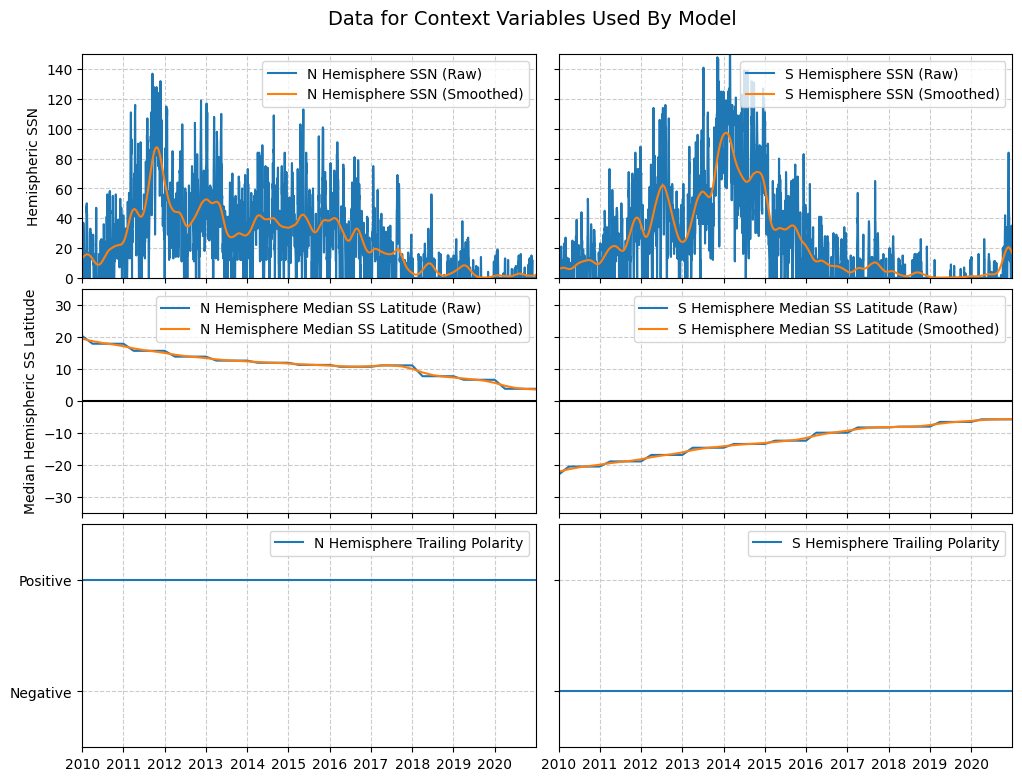

In [68]:
import pylab as plt
from datetime import datetime

stime = datetime(2010, 1, 1)
etime = datetime(2020, 12, 31)


fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharey='row', sharex=True)

ax = axes[0, 0]
ax.plot(df_hemi_ss.times, df_hemi_ss.sunspot_north, '-', label='N Hemisphere SSN (Raw)')
ax.plot(df_hemi_ss.times, df_hemi_ss.sunspot_north_smooth, label='N Hemisphere SSN (Smoothed)')
ax.set_ylim(0, 150)
ax.legend(loc='upper right')
ax.set_ylabel('Hemispheric SSN')

ax = axes[0, 1]
ax.plot(df_hemi_ss.times, df_hemi_ss.sunspot_south, '-', label='S Hemisphere SSN (Raw)')
ax.plot(df_hemi_ss.times, df_hemi_ss.sunspot_south_smooth, label='S Hemisphere SSN (Smoothed)')
ax.set_ylim(0, 150)
ax.legend(loc='upper right')

ax = axes[1, 0]
ax.plot(df_hemi_lat.times, df_hemi_lat.MedianLatNorth, '-', label='N Hemisphere Median SS Latitude (Raw)')
ax.plot(df_hemi_lat.times, df_hemi_lat.MedianLatNorth_Smoothed, '-', label='N Hemisphere Median SS Latitude (Smoothed)')
ax.legend()
ax.axhline(0, color='k')
ax.set_ylabel('Median Hemispheric SS Latitude')

ax = axes[1, 1]
ax.plot(df_hemi_lat.times, df_hemi_lat.MedianLatSouth, '-', label='S Hemisphere Median SS Latitude (Raw)')
ax.plot(df_hemi_lat.times, df_hemi_lat.MedianLatSouth_Smoothed, '-', label='S Hemisphere Median SS Latitude (Smoothed)')
ax.legend()
ax.set_ylim(-35, 35)
ax.axhline(0, color='k')

ax = axes[2, 0]
ax.plot(df_hemi_lat.times, np.ones_like(df_hemi_lat.times, dtype=float), label='N Hemisphere Trailing Polarity')
ax.legend()

ax = axes[2, 1]
ax.plot(df_hemi_lat.times, -np.ones_like(df_hemi_lat.times, dtype=float), label='S Hemisphere Trailing Polarity')
ax.set_ylim(-2, 2)
ax.set_yticks([-1, 1])
ax.set_yticklabels(['Negative', 'Positive'])
ax.legend()

for ax in axes.flatten():
    ax.set_xlim(stime, etime)
    ax.grid(color='#cccccc', linestyle='dashed')
fig.subplots_adjust(wspace=0.05, hspace=0.05)
fig.suptitle('Data for Context Variables Used By Model', y=0.93, fontsize=14)
fig.savefig('plots/paper/contextdata.png', dpi=300)